INTRODUCTION

The data we are using comes from OpenFoodFacts. It mostly looks at snacks, things like chips or cookies, candy too.

We did some parsing on the ingredients. That helped spot additives and get a sense of how foods are put together, patterns and all that. It seems kind of useful to see those connections.

This one builds on it a little. We apply machine learning models here. The idea is to sort products, put them in high risk or low risk groups. Based on if there are additives, and also how complex the ingredients look, I guess. That part gets a bit messy to explain fully.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

DATA COLLECTION



In [ ]:
file_path = r"C:\ctd_data\en.openfoodfacts.org.products.csv"

cols = ["product_name", "categories_en", "ingredients_text"]

keywords = ["chips", "crisps", "cookies", "biscuits","cake", "chocolate", "candy", "bar", "cracker"]

collected_data = []

chunks = pd.read_csv(file_path,sep="\t",usecols=cols,chunksize=50000,low_memory=False,on_bad_lines='skip',encoding="utf-8")

for i, chunk in enumerate(chunks):

    # filter's snack categories
    chunk = chunk[chunk["categories_en"].str.contains("|".join(keywords), case=False, na=False)]

    # remove missing ingredient rows
    chunk = chunk.dropna(subset=["ingredients_text"])

    # duplicates removed
    chunk = chunk.drop_duplicates(subset=["product_name", "ingredients_text"])

    collected_data.append(chunk)

    if i % 5 == 0:
        print(f"Processed {i} chunks")

Processed 0 chunks
Processed 5 chunks
Processed 10 chunks
Processed 15 chunks
Processed 20 chunks
Processed 25 chunks
Processed 30 chunks
Processed 35 chunks
Processed 40 chunks
Processed 45 chunks
Processed 50 chunks
Processed 55 chunks
Processed 60 chunks
Processed 65 chunks
Processed 70 chunks
Processed 75 chunks
Processed 80 chunks
Processed 85 chunks


COMBINE AND SAMPLE

In [3]:
df = pd.concat(collected_data).reset_index(drop=True)

print("Before sampling:", df.shape)

df = df.sample(n=min(100000, len(df)), random_state=42)

print("After sampling:", df.shape)

Before sampling: (152360, 3)
After sampling: (100000, 3)


SAVE AND RELOAD DATA

OpenFoodFacts data is quite huge (more than 12GB) and therefore cannot be loaded into the memory. In order to counter that, the processing of the dataset was carried out in batches. Only pertinent columns were used and the data was filtered to bring about snack related products.

Data quality was enhanced by deleting rows containing no text in the ingredient field and also by deleting duplicates. Upon filtering, the data set was pooled and a sample of about 100000 rows was taken to further analysis.

Interpretation:
Fast processing of large-scale real-world data is possible by the use of chunk-based processing. In such a way, the emphasis on the category of snacks makes the analysis more specific and related to the aims of the research. Sampling makes the computations possible and the sample representative of the data.

In [ ]:
df.to_csv("snacks_large_sample.csv", index=False)

# reloading for modeling phase
df = pd.read_csv("snacks_large_sample.csv")

print(df.shape)

(100000, 3)


CLEAN INGREDIENT TEXT

In [5]:
def clean_ingredients(text):
    text = str(text).lower()

    text = re.sub(r"\(.*?\)", "", text)
    text = text.replace(";", ",")
    text = text.replace(".", ",")

    text = re.sub(r"[^a-z0-9, ]", "", text)

    ingredients = [i.strip() for i in text.split(",") if i.strip()]
    return ingredients

df["ingredients_list"] = df["ingredients_text"].apply(clean_ingredients)
df["ingredient_count"] = df["ingredients_list"].apply(len)

DEFINE ADDITIVES

Constructed a pre-specified list of ingredients that typically are additives such as preservatives, artificial colors, sweeteners like sodium benzoate, MSG, aspartame, tartrazine, Red 40 etc.

Used keyword matching on ingredients to flag whether or not each product contains each of these additives. Created binary indicators for each additive as well as overall count of additives.

Explanation: 
Flagging additives is one way to convert the free text ingredient list into structured signals. The additives were chosen as they are commonly used and may be related to processed foods in general. This list of additives is not comprehensive but contains a useful subset.

In [6]:
additives_dict = {
    "sodium_benzoate": ["sodium benzoate", "e211"],
    "msg": ["monosodium glutamate", "msg"],
    "aspartame": ["aspartame", "e951"],
    "tartrazine": ["tartrazine", "e102"],
    "red_40": ["red 40", "e129"],
    "yellow_6": ["yellow 6", "e110"]
}

DETECT ADDITIVES

In [7]:
def detect_additives(ingredients):
    found = []

    for ing in ingredients:
        for chem, names in additives_dict.items():
            for name in names:
                if name in ing:
                    found.append(chem)
                    break

    return list(set(found))

df["detected_additives"] = df["ingredients_list"].apply(detect_additives)

FEATURE ENGINEERING
Features created included ingredient and additive information: 

Number of ingredients 
Number of additives 
Density of additives (number of additives/number of ingredients)
Binary columns for each additive 

Explanation: 
Essentially, these features outline both the complexity of the product and how many chemicals it has been exposed to. Density works better than simply counting additives as it scales the exposure to the length of ingredients.

In [8]:
for chem in additives_dict:
    df[f"has_{chem}"] = df["detected_additives"].apply(lambda x: int(chem in x))

df["total_additives"] = df["detected_additives"].apply(len)
df["additive_density"] = df["total_additives"] / (df["ingredient_count"] + 1)

CREATE TARGET VARIABLE

Risk Score: Defined by the total count of detected additives. More additives = higher risk product. 

Binary Label: Median split of Risk Score 

Interpretation: Allows for an easily interpretable definition of risk. Although this is not clinical toxicity, we can classify products equally by their additive content for the purpose of this research.

In [9]:
df["risk_score"] = df["total_additives"]

threshold = df["risk_score"].median()
df["risk_label"] = (df["risk_score"] > threshold).astype(int)

In [21]:
df["risk_label"].value_counts(normalize=True)

risk_label
0    0.968138
1    0.031862
Name: proportion, dtype: float64

DATA CHECK

Ingredient count distribution is highly right-skewed. Product mostly has between 5-20 ingredients with few exceptions which have way higher values.

Distribution for additive count: 

Product has mostly 0 or very less of the given additives.

Conclusion: 
Ingredient distribution was skewed as expected. There are more or less products with high/low number of ingredients. Since there are only 85 additives considered out of all the possible ingredients, it is obvious that additive column value would be sparse. We also see class imbalance here. This will be kept in mind while creating the model.

In [17]:
# remove extreme outliers
df = df[df["ingredient_count"] < 100]

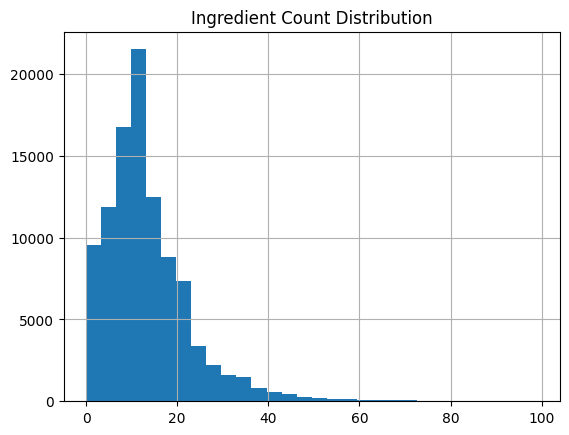

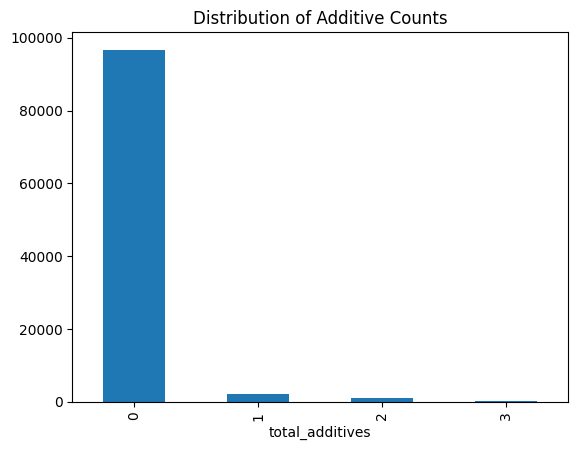

In [20]:
df["ingredient_count"].hist(bins=30)
plt.title("Ingredient Count Distribution")
plt.show()

df["total_additives"].value_counts()

df["total_additives"].value_counts().plot(kind="bar")
plt.title("Distribution of Additive Counts")
plt.show()

PREPARE DATA FOR ML

The training and test sets were divided into a training and test sample with an engaging stratified sample to continue class allocation. In order to assess the firmness of the model, cross-validation has been applied.Multiple machine learning models were trained:Logistic Regression,LDA,KNN,Random Forest,Hyperparameter tuning was performed for Random Forest using GridSearchCV.

Interpretation:The use of several models allows comparing the various approaches to education. Cross-validation ensures that the model's performance is stable and not dependent on any particular information split.


In [11]:
feature_cols = ["ingredient_count", "total_additives", "additive_density"] + \
               [f"has_{c}" for c in additives_dict]

X = df[feature_cols]
y = df["risk_label"]

TRAIN-TEST SPLIT

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

CROSS VALIDATION

In [13]:
lr = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(lr, X_train, y_train, cv=5)

print("Mean CV score:", cv_scores.mean())

Mean CV score: 1.0


MODEL TRAINING

The models achieved very high accuracy:Logistic Regression: 1.0, LDA: 0.998, KNN: 0.999, Random Forest: 1.0

Interpretation:
Near-perfect performance is mainly due to the method of determining the target variable. Because the danger label can be inferred from an additively related feature, the model is able to study forms that are already present in the data.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = model.score(X_test, y_test)

print(results)

{'Logistic Regression': 1.0, 'LDA': 0.9982, 'KNN': 0.99955, 'Random Forest': 1.0}


HYPERPARAMETER TUNING

In [15]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(rf, param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 50}


FINAL EVALUATION

In [16]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19362
           1       1.00      1.00      1.00       638

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



Model Selection and Interpretation:

A strong link between linear attendance and the established hazard metric is apparent in the high accuracy rate. However, this also introduces a structure of information escape since the same features used for determining the target are used for the prediction.

Interpretation:While the model performs competently, one's anticipatory control is limited to this precise risk formulation. This highlights the importance of careful features and target design in the process of acquiring knowledge by machines.


Logistic Regression is selected as the preferred model due to its simplicity and interpretability.
Interpretation:Although a more involved model achieved the same results, logistic regression provides a clear understanding of the aid and is easy to justify in an intellectual context.

LIMITATIONS:

Risk label based on additive feature (data leakage) Limited number of additives External validation limited Ingredient parsing may add noise Interpretation: Should interpret as an exploratory tool, not confident risk assessment.

CONCLUSION:
In this work, it is shown that additive-based features may be used for classifying packed snack foods according to their risk category. The results show good classification scores despite being heavily dependent on the definition of the target variable. Future work shall involve including independent measures of risk, covering more additives and validating on an external data-set.

AI USAGE STATEMENT:
I used an AI tool as assistive technology to help get a sense of the structure of the work whilst coding and the approach to implement the concepts. Nonetheless, all the code was written by me except those portions explicitly stated and under my complete control with thorough understanding. Interpretations, feature designs and models were made based on my understanding of the dataset and the problem.